# AndinaExpress S.A.S. — Análisis Exploratorio de Datos

## 0. Carga de datos

In [ ]:
import pandas as pd
import numpy as np
import unicodedata
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

FILENAME = "AndinaExpress_datosPARCIAL_2025.xlsx"

df = pd.read_excel(FILENAME, sheet_name="Datos")
df.columns = [c.strip() for c in df.columns] 
print(df.shape)
df.head()

(1550, 18)


,id_envio,fecha_despacho,ciudad,zona,tipo_servicio,canal_venta,transportadora,distancia_km,peso_kg,tiempo_entrega_h,costo_flete_cop,valor_declarado_cop,intentos_entrega,devuelto,cadena_frio,temperatura_recepcion_c,calificacion_cliente,observaciones
0,AE-2025-00881,02/05/2025,Villavicencio,Rural,Estandar,Tienda propia,LogiSur,21.8,2.92,92.06,17950,531400,2,No,No,NaN,4.0,NaN
1,AE-2025-00446,21/05/2025,Bogota D.C.,Urbana,Express,Tienda propia,AndinaExpress,11.6,1.30,12.29,16700,217300,1,No,No,NaN,5.0,NaN
2,AE-2025-00841,2025-03-25,BOGOTA D.C.,Urbana,Same-day,Marketplace,LogiSur,25.0,8.28,-999.00,41250,955400,1,No,Si,5.55,3.0,NaN
3,AE-2025-01023,03/04/2025,Bogota D.C.,Urbana,Estandar,Marketplace,TransPacífico,1.8,1.75,18.03,11450,4100,1,No,No,NaN,5.0,NaN
4,AE-2025-00661,07-03-25,Bogota D.C.,Urbana,Estandar,Marketplace,AndinaExpress,4.1,4.27,11.80,13900,387000,1,No,No,NaN,5.0,NaN


## 1. Diagnóstico de calidad

Revisamos cada columna, se listan los problemas encontrados y su magnitud

In [2]:
print("Nulos por columna:")
print(df.isna().sum())
print("\nid_envio duplicados:", df['id_envio'].duplicated().sum())
print("\nCiudades distintas (crudo):", df['ciudad'].nunique(), "→ solo debería haber 10")
print("Transportadoras distintas (crudo):", df['transportadora'].nunique(), "→ solo debería haber 4")
print("Valores distintos de 'devuelto':", sorted(df['devuelto'].dropna().unique().tolist(), key=str))
print("\nFormatos de fecha_despacho (muestra):", df['fecha_despacho'].astype(str).sample(5, random_state=0).tolist())
print("\npeso_kg <= 0:", (df['peso_kg']<=0).sum(), " | peso_kg > 80 (límite contractual):", (df['peso_kg']>80).sum())
print("tiempo_entrega_h con valor centinela -999:", (df['tiempo_entrega_h']==-999).sum(), " | tiempo_entrega_h == 0:", (df['tiempo_entrega_h']==0).sum())
print("intentos_entrega == 0:", (df['intentos_entrega']==0).sum())
print("calificacion_cliente fuera de 1-5:", (~df['calificacion_cliente'].between(1,5) & df['calificacion_cliente'].notna()).sum())
print("cadena_frio='No' pero con temperatura registrada:", ((df['cadena_frio']=='No') & df['temperatura_recepcion_c'].notna()).sum())
print("costo_flete_cop con formato de texto ('$ 24.900', etc.):", df['costo_flete_cop'].apply(lambda x: isinstance(x,str)).sum())
print("\nCobertura de calificacion_cliente por canal_venta:")
print(df.groupby('canal_venta')['calificacion_cliente'].apply(lambda s: s.notna().mean()*100).round(1))

Nulos por columna:
id_envio                      0
fecha_despacho                0
ciudad                        0
zona                          0
tipo_servicio                 0
canal_venta                   0
transportadora                0
distancia_km                 65
peso_kg                       0
tiempo_entrega_h              0
costo_flete_cop               0
valor_declarado_cop           0
intentos_entrega              0
devuelto                     13
cadena_frio                   0
temperatura_recepcion_c    1240
calificacion_cliente        406
observaciones              1525
dtype: int64

id_envio duplicados: 50

Ciudades distintas (crudo): 30 → solo debería haber 10
Transportadoras distintas (crudo): 14 → solo debería haber 4
Valores distintos de 'devuelto': [0, 1, 'FALSE', 'N', 'NO', 'No', 'S', 'SI', 'Si', 'Sí', 'TRUE', 'no', 'si']

Formatos de fecha_despacho (muestra): ['2025-05-31', '2025-05-13', '2025-05-22', '2025-04-12', '2025-04-05']

peso_kg <= 0: 13  | peso_kg > 

## 2. Limpieza de datos


In [3]:
log = [] 

n0 = len(df)
df = df.drop_duplicates(subset='id_envio', keep='first').reset_index(drop=True)
log.append(("Registros duplicados por id_envio (recarga WMS) eliminados", n0 - len(df)))
print(log[-1])

('Registros duplicados por id_envio (recarga WMS) eliminados', 50)


In [ ]:
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def clean_ciudad(x):
    s = strip_accents(str(x).strip().upper())
    s = re.sub(r'\s+', ' ', s).replace('.', '')
    if s.startswith('BOGOTA'):
        return 'Bogota D.C.'
    return s.title()

n_variantes = df['ciudad'].nunique()
df['ciudad'] = df['ciudad'].apply(clean_ciudad)
log.append((f"Ciudad: {n_variantes} grafías unificadas en {df['ciudad'].nunique()} ciudades", n0))
print(df['ciudad'].value_counts())

ciudad
Bogota D.C.      360
Medellin         237
Cali             190
Barranquilla     142
Villavicencio    140
Bucaramanga      120
Pasto            113
Monteria          94
Florencia         59
Quibdo            45
Name: count, dtype: int64


In [ ]:
def clean_transportadora(x):
    s = strip_accents(str(x).strip().upper())
    s = re.sub(r'\s+', '', s)
    mapping = {'ANDINAEXPRESS': 'AndinaExpress', 'LOGISUR': 'LogiSur',
               'RAPIDOCARIBE': 'RapidoCaribe', 'TRANSPACIFICO': 'TransPacifico'}
    return mapping.get(s, s)

n_variantes = df['transportadora'].nunique()
df['transportadora'] = df['transportadora'].apply(clean_transportadora)
log.append((f"Transportadora: {n_variantes} grafías unificadas en {df['transportadora'].nunique()} operadores", n0))
print(df['transportadora'].value_counts())

transportadora
AndinaExpress    599
LogiSur          387
RapidoCaribe     271
TransPacifico    243
Name: count, dtype: int64


In [ ]:
map_devuelto = {'Si':'Si','SI':'Si','si':'Si','S':'Si','S\u00ed':'Si','TRUE':'Si','1':'Si',
                'No':'No','NO':'No','no':'No','N':'No','FALSE':'No','0':'No'}
n_faltan = df['devuelto'].isna().sum()
df['devuelto'] = df['devuelto'].astype(str).map(map_devuelto)
df.loc[df['devuelto'].isna() & (df['devuelto']!='Si') & (df['devuelto']!='No'), 'devuelto'] = np.nan
log.append(("devuelto: 14 codificaciones distintas unificadas a Si/No; sin dato se deja vacío", n_faltan))
print(df['devuelto'].value_counts(dropna=False))

devuelto
No     1389
Si       99
NaN      12
Name: count, dtype: int64


In [ ]:
def parse_fecha(s):
    s = str(s).strip()
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT 

df['fecha_despacho'] = df['fecha_despacho'].apply(parse_fecha)
n_invalida = df['fecha_despacho'].isna().sum()
log.append(("Fechas normalizadas a datetime desde 3 formatos distintos", n0))
log.append(("Fechas con calendario inválido (no existen, ej. 31/02) -> vacío", n_invalida))

fuera_rango = df['fecha_despacho'].notna() & ~df['fecha_despacho'].between('2025-03-01', '2025-05-31')
n_fuera = fuera_rango.sum()
df.loc[fuera_rango, 'fecha_despacho'] = pd.NaT
log.append(("Fechas fuera del trimestre marzo-mayo 2025 (año/mes errado) -> vacío", n_fuera))

print("Total fechas vaciadas:", df['fecha_despacho'].isna().sum())
print(df['fecha_despacho'].min(), "→", df['fecha_despacho'].max())

Total fechas vaciadas: 11
2025-03-01 00:00:00 → 2025-05-31 00:00:00


In [ ]:
def parse_costo(x):
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).replace('$', '').replace(' ', '').replace('.', '')
    return float(s)

n_texto = df['costo_flete_cop'].apply(lambda x: isinstance(x, str)).sum()
df['costo_flete_cop'] = df['costo_flete_cop'].apply(parse_costo)
log.append(("costo_flete_cop: valores en texto con '$' y separador de miles convertidos a número", n_texto))
n_credito = (df['costo_flete_cop'] < 0).sum()
log.append(("costo_flete_cop negativo (nota de crédito documentada, se conserva)", n_credito))
print(df['costo_flete_cop'].describe())

count      1500.000000
mean      34086.533333
std       30846.451460
min     -545000.000000
25%       19100.000000
50%       27475.000000
75%       41450.000000
max      246400.000000
Name: costo_flete_cop, dtype: float64


In [ ]:
n_invalido = (df['peso_kg'] <= 0).sum()
df.loc[df['peso_kg'] <= 0, 'peso_kg'] = np.nan
log.append(("peso_kg <= 0 (físicamente imposible) -> vacío", n_invalido))

n_gramos = (df['peso_kg'] > 80).sum()
df.loc[df['peso_kg'] > 80, 'peso_kg'] = df.loc[df['peso_kg'] > 80, 'peso_kg'] / 1000
log.append(("peso_kg > 80kg (límite contractual): registrado en gramos, dividido por 1000", n_gramos))
print(df['peso_kg'].describe())

count    1488.000000
mean        7.442789
std        11.457839
min         0.120000
25%         1.900000
50%         3.575000
75%         7.190000
max        64.870000
Name: peso_kg, dtype: float64


In [ ]:
n_centinela = (df['tiempo_entrega_h'] == -999).sum()
n_cero = (df['tiempo_entrega_h'] == 0).sum()
df.loc[df['tiempo_entrega_h'].isin([-999, 0]), 'tiempo_entrega_h'] = np.nan
log.append(("tiempo_entrega_h = -999 (centinela de faltante) -> vacío", n_centinela))
log.append(("tiempo_entrega_h = 0 (imposible) -> vacío", n_cero))
print(df['tiempo_entrega_h'].describe())

count    1455.000000
mean       33.139787
std        48.544918
min         1.150000
25%        11.100000
50%        20.230000
75%        42.440000
max       772.260000
Name: tiempo_entrega_h, dtype: float64


In [ ]:
n_cero = (df['intentos_entrega'] == 0).sum()
df.loc[df['intentos_entrega'] == 0, 'intentos_entrega'] = 1
log.append(("intentos_entrega = 0 corregido a 1 (mínimo del dominio)", n_cero))


n_fuera = (~df['calificacion_cliente'].between(1, 5) & df['calificacion_cliente'].notna()).sum()
df.loc[~df['calificacion_cliente'].between(1, 5) & df['calificacion_cliente'].notna(), 'calificacion_cliente'] = np.nan
log.append(("calificacion_cliente fuera de escala 1-5 (valores 0 y 6) -> vacío", n_fuera))
print("intentos_entrega min:", df['intentos_entrega'].min(), "| calificacion_cliente rango:", df['calificacion_cliente'].min(), "-", df['calificacion_cliente'].max())

intentos_entrega min: 1 | calificacion_cliente rango: 1.0 - 5.0


In [ ]:
inconsistentes = (df['cadena_frio'] == 'No') & df['temperatura_recepcion_c'].notna()
n_inc = inconsistentes.sum()
df.loc[inconsistentes, 'cadena_frio'] = 'Si'
log.append(("cadena_frio corregido a 'Si' por tener temperatura registrada (inconsistencia con el flag)", n_inc))
print(log[-1])

("cadena_frio corregido a 'Si' por tener temperatura registrada (inconsistencia con el flag)", np.int64(9))


### Registro de correcciones aplicadas

In [13]:
log_df = pd.DataFrame(log, columns=['Corrección', 'Registros afectados'])
log_df

,Corrección,Registros afectados
0,Registros duplicados por id_envio (recarga WMS...,50
1,Ciudad: 30 grafías unificadas en 10 ciudades,1550
2,Transportadora: 14 grafías unificadas en 4 ope...,1550
3,devuelto: 14 codificaciones distintas unificad...,12
4,Fechas normalizadas a datetime desde 3 formato...,1550
5,"Fechas con calendario inválido (no existen, ej...",5
6,Fechas fuera del trimestre marzo-mayo 2025 (añ...,6
7,costo_flete_cop: valores en texto con '$' y se...,230
8,costo_flete_cop negativo (nota de crédito docu...,5
9,peso_kg <= 0 (físicamente imposible) -> vacío,12


## P1. ¿Qué tiempo de entrega puede prometer la empresa en su sitio web?


Mediana: 20.2 h | P90: 72.9 h | P95: 89.6 h | Media: 33.1 h


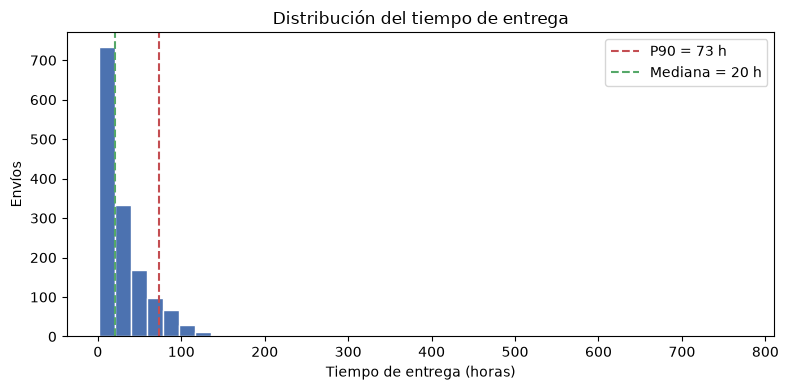

In [14]:
t = df['tiempo_entrega_h'].dropna()
p50, p90, p95 = t.quantile([0.5, 0.9, 0.95])
print(f"Mediana: {p50:.1f} h | P90: {p90:.1f} h | P95: {p95:.1f} h | Media: {t.mean():.1f} h")

plt.figure(figsize=(8,4))
plt.hist(t, bins=40, color='#4C72B0', edgecolor='white')
plt.axvline(p90, color='#C44E52', linestyle='--', label=f'P90 = {p90:.0f} h')
plt.axvline(p50, color='#55A868', linestyle='--', label=f'Mediana = {p50:.0f} h')
plt.xlabel('Tiempo de entrega (horas)'); plt.ylabel('Envíos'); plt.title('Distribución del tiempo de entrega')
plt.legend(); plt.tight_layout(); plt.show()

## P2. ¿El tiempo de entrega es igual en zona urbana que en zona rural?

        median       mean  count
zona                            
Rural   58.780  72.626520    439
Urbana  14.235  16.078098   1016


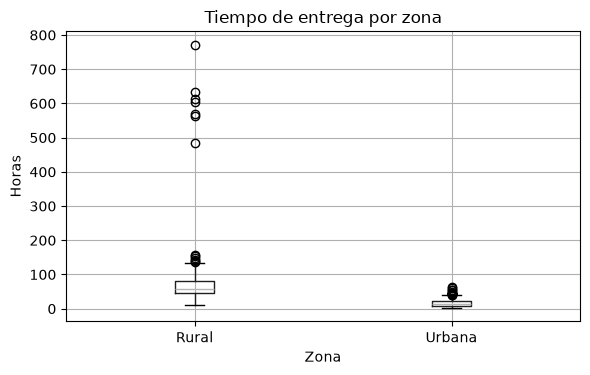

In [15]:
resumen = df.groupby('zona')['tiempo_entrega_h'].agg(['median','mean','count'])
print(resumen)

plt.figure(figsize=(6,4))
df.boxplot(column='tiempo_entrega_h', by='zona', ax=plt.gca())
plt.suptitle('')
plt.title('Tiempo de entrega por zona')
plt.ylabel('Horas'); plt.xlabel('Zona')
plt.tight_layout(); plt.show()

## P3. ¿Con qué transportadora se debe renegociar la tarifa?


                costo_km_mediano  tiempo_entrega_mediano  tasa_devolucion  \
transportadora                                                              
AndinaExpress            1415.03                   20.34             0.07   
LogiSur                  1459.52                   22.10             0.07   
RapidoCaribe             1481.29                   19.30             0.05   
TransPacifico            1562.50                   20.26             0.07   

                envios  
transportadora          
AndinaExpress      596  
LogiSur            386  
RapidoCaribe       270  
TransPacifico      243  


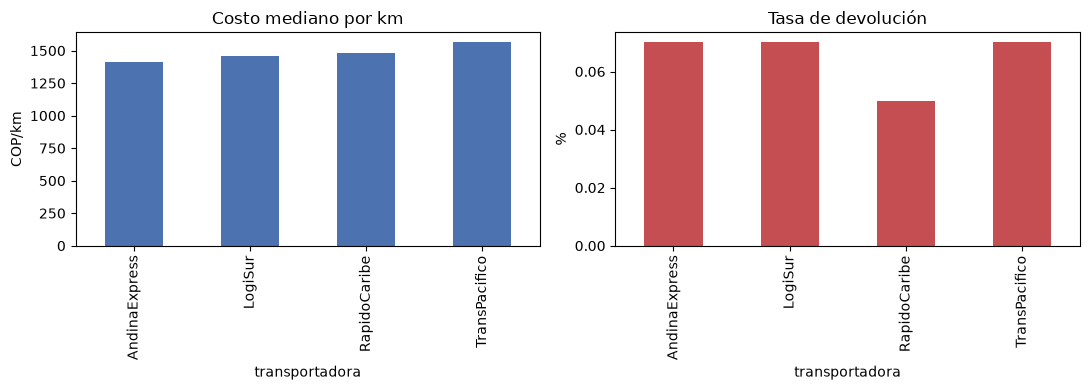

In [16]:
df['costo_por_km'] = df['costo_flete_cop'] / df['distancia_km']
tabla = df[df['costo_flete_cop']>0].groupby('transportadora').agg(
    costo_km_mediano=('costo_por_km','median'),
    tiempo_entrega_mediano=('tiempo_entrega_h','median'),
    tasa_devolucion=('devuelto', lambda s: (s=='Si').mean()),
    envios=('id_envio','count')
).round(2)
print(tabla)

fig, axes = plt.subplots(1,2, figsize=(11,4))
tabla['costo_km_mediano'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Costo mediano por km'); axes[0].set_ylabel('COP/km')
tabla['tasa_devolucion'].plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Tasa de devolución'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()

## P4. ¿Sobre qué valor se debe tarifar el seguro de la mercancía?


count    1.500000e+03
mean     2.202472e+06
std      4.272069e+07
min      1.600000e+03
25%      5.222500e+04
50%      1.166500e+05
75%      2.497250e+05
max      1.515700e+09
Name: valor_declarado_cop, dtype: float64

P50: 116650.0 | P75: 249725.0 | P90: 510920.0000000009
Envíos con valor > 50M COP (outliers extremos): 8


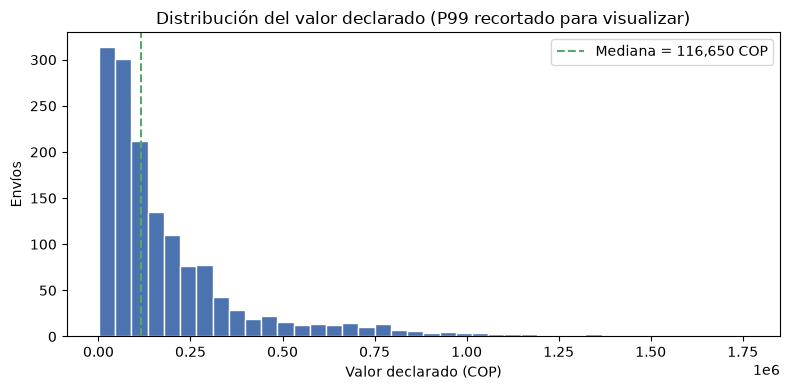

In [17]:
v = df['valor_declarado_cop']
print(v.describe())
print("\nP50:", v.median(), "| P75:", v.quantile(0.75), "| P90:", v.quantile(0.90))
print("Envíos con valor > 50M COP (outliers extremos):", (v>50_000_000).sum())

plt.figure(figsize=(8,4))
plt.hist(v[v<v.quantile(0.99)], bins=40, color='#4C72B0', edgecolor='white')
plt.axvline(v.median(), color='#55A868', linestyle='--', label=f'Mediana = {v.median():,.0f} COP')
plt.xlabel('Valor declarado (COP)'); plt.ylabel('Envíos')
plt.title('Distribución del valor declarado (P99 recortado para visualizar)')
plt.legend(); plt.tight_layout(); plt.show()

## P5. ¿Cuántas visitas hace la empresa por envío y dónde se concentran las repetidas?

count    1500.000000
mean        1.353333
std         0.631998
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: intentos_entrega, dtype: float64

% de envíos con más de 1 intento: 28.333333333333332 %


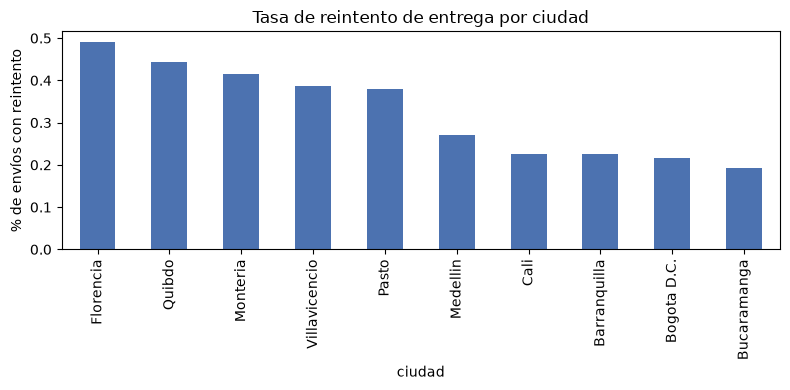

In [18]:
print(df['intentos_entrega'].describe())
print("\n% de envíos con más de 1 intento:", (df['intentos_entrega']>1).mean()*100, "%")

repetidos = df[df['intentos_entrega']>1]
por_ciudad = repetidos.groupby('ciudad').size().sort_values(ascending=False) / df.groupby('ciudad').size()

plt.figure(figsize=(8,4))
por_ciudad.sort_values(ascending=False).plot(kind='bar', color='#4C72B0')
plt.ylabel('% de envíos con reintento'); plt.title('Tasa de reintento de entrega por ciudad')
plt.tight_layout(); plt.show()

## P6. ¿Cuál canal de venta tiene mejor calificación del cliente?

Cobertura de la encuesta por canal (% de envíos con calificación registrada):
canal_venta
Call center       0.0
Marketplace      92.7
Tienda propia    92.9
Name: calificacion_cliente, dtype: float64
               mean  median  count
canal_venta                       
Call center     NaN     NaN      0
Marketplace    4.15     5.0    618
Tienda propia  4.18     5.0    482


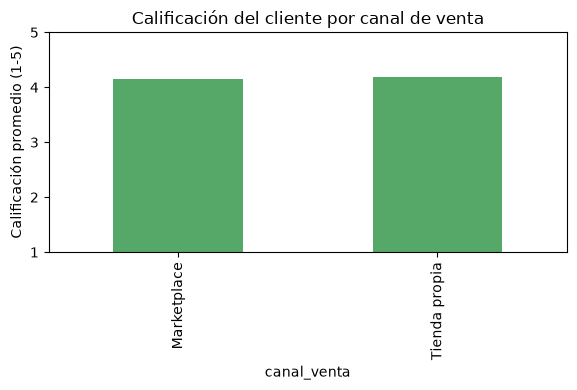

In [19]:
cobertura = df.groupby('canal_venta')['calificacion_cliente'].apply(lambda s: s.notna().mean()*100).round(1)
print("Cobertura de la encuesta por canal (% de envíos con calificación registrada):")
print(cobertura)

resumen = df.groupby('canal_venta')['calificacion_cliente'].agg(['mean','median','count']).round(2)
print(resumen)

plt.figure(figsize=(6,4))
resumen['mean'].dropna().plot(kind='bar', color='#55A868')
plt.ylabel('Calificación promedio (1-5)'); plt.title('Calificación del cliente por canal de venta')
plt.ylim(1,5)
plt.tight_layout(); plt.show()